In [1]:
import numpy as np
import gamry_parser
import glob
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display
import os
import re
from scipy.optimize import differential_evolution, minimize, least_squares
from impedance.models.circuits import CustomCircuit
from impedance.models.circuits.elements import element
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import ScalarFormatter
import impedance.models.circuits.fitting as fitting


In [2]:
TARGET_DIR = Path(r"C:\Users\Alexa\Desktop\EIS for Alexandre Cauvel\AA2024 case")

# 2. Get all files in that directory (filtered for .DTA files)
available_files = sorted([f.name for f in TARGET_DIR.glob("*.DTA") if f.is_file()])

# 3. Create the multi-selection widget
file_selector = widgets.SelectMultiple(
    options=available_files,
    value=[], # Initial empty selection
    rows=10,  # Number of visible items in the window box
    description='Files:',
    disabled=False,
    layout=widgets.Layout(width='50%')
)

print(f"Directory: {TARGET_DIR}")
display(file_selector)

Directory: C:\Users\Alexa\Desktop\EIS for Alexandre Cauvel\AA2024 case


SelectMultiple(description='Files:', layout=Layout(width='50%'), options=('7_Bare_AA2024_1.DTA', '7_Bare_AA202…

In [4]:
file_list = [TARGET_DIR / filename for filename in file_selector.value]
print(file_list)

[WindowsPath('C:/Users/Alexa/Desktop/EIS for Alexandre Cauvel/AA2024 case/Vasco_LNV3_4.DTA')]


In [5]:
all_datasets = []

for filename in file_list:
    parser = gamry_parser.GamryParser()
    parser.load(filename)
    data = parser.curves[0]
    header_data = parser.get_header()
    original_eis_data = {
        'name': filename.stem,
        'Zreal':data['Zreal'].values*header_data.get('AREA'),
        'Zimag':-data['Zimag'].values*header_data.get('AREA'),
        'Z_data':data['Zreal'].values*header_data.get('AREA') + 1j*data['Zimag'].values*header_data.get('AREA'),
        'Zmod':data['Zmod'].values*header_data.get('AREA'),
        'Zphz':data['Zphz'].values,
        'Freq':data['Freq'].values,
        'area':header_data.get('AREA'),
        'circuit':None,
        'Z_fit':None,
        'chi_sq': None,
        'param_errors': None
    }

    eis_data = {
        'name': filename.stem,
        'Zreal':None,
        'Zimag':None,
        'Zmod':None,
        'Zphz':None,
        'Z_data':None,
        'Freq':None,
        'circuit':None,
        'Z_fit':None,
        'chi_sq':None,
        'param_errors': None
    }
    
    all_datasets.append({"eis_data":eis_data, "original_eis_data":original_eis_data})

In [49]:
@element(num_params=2, units=['S*sec^1/2', 'sec^1/2'],overwrite = True)
def PW(p, f):
    """
    Gamry's 'O' Element: Porous Bounded Warburg
    p[0] = Yo (Admittance coefficient)
    p[1] = B (Time constant parameter)
    """
    # CRITICAL FIX: Convert the incoming list into a NumPy array
    f = np.array(f)
    
    omega = 2 * np.pi * f
    Yo, B = p[0], p[1]
    
    # Calculate the square root of (j * omega)
    s_j_omega = np.sqrt(1j * omega)
    
    # Implement coth(x) using 1 / tanh(x)
    coth_term = 1 / np.tanh(B * s_j_omega)
    
    # Final impedance calculation
    Z = coth_term / (Yo * s_j_omega)
    return Z

In [6]:
circuits_data = {
    '1RC': {
        'string': 'R0-p(R1,CPE1)',
        'bounds': {
            'R0':     {'bounds': (1, 1e3),     'log': True},
            'R1':     {'bounds': (1, 1e8),     'log': True},
            'CPE1_0': {'bounds': (1e-9, 1e-3), 'log': True},
            'CPE1_1': {'bounds': (0.5, 1.0),   'log': False},
        }
    },
    '2RC': {
        'string': 'R0-p(R1-p(R2,CPE2),CPE1)',
        'bounds': {
            'R0':     {'bounds': (1, 1e3),     'log': True},
            'R1':     {'bounds': (1, 1e8),     'log': True},
            'R2':     {'bounds': (1, 1e12),     'log': True},
            'CPE2_0': {'bounds': (1e-9, 1e-2), 'log': True},
            'CPE2_1': {'bounds': (0.5, 1.0),   'log': False},
            'CPE1_0': {'bounds': (1e-9, 1e-3), 'log': True},
            'CPE1_1': {'bounds': (0.5, 1.0),   'log': False},
        }
    },
    '1RC-PW': {
        'string': 'R0-p(R1-PW1,CPE1)',
        'bounds': {
            'R0':     {'bounds': (1, 1e3),     'log': True},
            'R1':     {'bounds': (1, 1e8),     'log': True},
            'PW1_0':  {'bounds': (1e-6, 1e2),  'log': True},
            'PW1_1':  {'bounds': (1e-3, 1e2),  'log': True},
            'CPE1_0': {'bounds': (1e-9, 1e-3), 'log': True},
            'CPE1_1': {'bounds': (0.5, 1.0),   'log': False},
        }
    },
    '2RC-PW': {
        'string': 'R0-p(R1-p(R2-PW2,CPE2),CPE1)',
        'bounds': {
            'R0':     {'bounds': (1, 1e3),     'log': True},
            'R1':     {'bounds': (1, 1e8),     'log': True},
            'R2':     {'bounds': (1, 1e12),    'log': True},
            'PW2_0':  {'bounds': (1e-6, 1e2),  'log': True},
            'PW2_1':  {'bounds': (1e-3, 1e2),  'log': True},
            'CPE2_0': {'bounds': (1e-9, 1e-2), 'log': True},
            'CPE2_1': {'bounds': (0.5, 1.0),   'log': False},
            'CPE1_0': {'bounds': (1e-9, 1e-3), 'log': True},
            'CPE1_1': {'bounds': (0.5, 1.0),   'log': False},
        }
    },
    '3RC': {
        'string': 'R0-p(R1-p(R2-p(R3,CPE3),CPE2),CPE1)',
        'bounds': {
            'R0':     {'bounds': (1, 1e3),     'log': True},
            'R1':     {'bounds': (1, 1e8),     'log': True},
            'R2':     {'bounds': (1, 1e8),     'log': True},
            'R3':     {'bounds': (1, 1e8),     'log': True},
            'CPE3_0': {'bounds': (1e-9, 1e-3), 'log': True},
            'CPE3_1': {'bounds': (0.2, 1.0),   'log': False},
            'CPE2_0': {'bounds': (1e-9, 1e-3), 'log': True},
            'CPE2_1': {'bounds': (0.2, 1.0),   'log': False},
            'CPE1_0': {'bounds': (1e-9, 1e-3), 'log': True},
            'CPE1_1': {'bounds': (0.2, 1.0),   'log': False},
        }
    },
    '4RC': {
        'string': 'R0-p(R1-p(R2-p(R3-p(R4,CPE4),CPE3),CPE2),CPE1)',
        'bounds': {
            'R0':     {'bounds': (1, 1e3),     'log': True},
            'R1':     {'bounds': (1, 1e8),     'log': True},
            'R2':     {'bounds': (1, 1e8),     'log': True},
            'R3':     {'bounds': (1, 1e8),     'log': True},
            'R4':     {'bounds': (1, 1e8),     'log': True},
            'CPE4_0': {'bounds': (1e-9, 1e-3), 'log': True},
            'CPE4_1': {'bounds': (0.1, 1.0),   'log': False},
            'CPE3_0': {'bounds': (1e-9, 1e-3), 'log': True},
            'CPE3_1': {'bounds': (0.1, 1.0),   'log': False},
            'CPE2_0': {'bounds': (1e-9, 1e-3), 'log': True},
            'CPE2_1': {'bounds': (0.1, 1.0),   'log': False},
            'CPE1_0': {'bounds': (1e-9, 1e-3), 'log': True},
            'CPE1_1': {'bounds': (0.1, 1.0),   'log': False},
        }
    }
}

In [13]:
def parameter_guesser(all_datasets, choice, data_key, circuits_data):
    """
    Guarantees global basin discovery over wide/unconstrained bounds using:
    - Exploratory Differential Evolution (randtobest1bin + dithered mutation)
    - Multi-Candidate Nelder-Mead polishing (Top-K population search)
    - High-precision Linear TRF refinement
    """
    circuit_string = circuits_data[choice]['string']
    param_dict = circuits_data[choice]['bounds']
    
    # 1. Parameter alignment
    dummy_circuit = CustomCircuit(circuit_string, initial_guess=[1.0] * len(param_dict))
    param_names = dummy_circuit.get_param_names()[0]

    ordered_bounds = []
    log_idx_list = []
    
    for idx, name in enumerate(param_names):
        bound_info = param_dict[name]
        ordered_bounds.append(bound_info['bounds'])
        if bound_info['log']:
            log_idx_list.append(idx)
            
    log_idx_arr = np.array(log_idx_list, dtype=int)

    lower_bounds, upper_bounds = zip(*ordered_bounds)
    fit_bounds = (list(lower_bounds), list(upper_bounds))

    log_bounds = [
        (np.log10(low), np.log10(high)) if idx in log_idx_arr else (low, high)
        for idx, (low, high) in enumerate(ordered_bounds)
    ]

    # 2. Process Datasets
    for i, dataset in enumerate(all_datasets):
        freq = dataset[data_key]['Freq']
        z_data = dataset[data_key]['Z_data']
        
        w_mod = np.abs(z_data)
        weight_sq = w_mod**2

        # Scalar loss function for DE & Nelder-Mead (Log-space)
        def scalar_objective(params):
            real_params = np.array(params, copy=True)
            real_params[log_idx_arr] = 10**real_params[log_idx_arr]

            try:
                circuit = CustomCircuit(circuit_string, initial_guess=real_params)
                z_fit = circuit.predict(freq)
                
                if np.any(np.isnan(z_fit)) or np.any(np.isinf(z_fit)):
                    return 1e15

                return np.sum(np.abs(z_data - z_fit)**2 / weight_sq)
            except Exception:
                return 1e15

        # Residual vector for Linear TRF
        def residual_vector_linear(linear_params):
            try:
                circuit = CustomCircuit(circuit_string, initial_guess=linear_params)
                z_fit = circuit.predict(freq)

                if np.any(np.isnan(z_fit)) or np.any(np.isinf(z_fit)):
                    return np.ones(2 * len(freq)) * 1e5

                r_real = (z_data.real - z_fit.real) / w_mod
                r_imag = (z_data.imag - z_fit.imag) / w_mod
                return np.concatenate([r_real, r_imag])
            except Exception:
                return np.ones(2 * len(freq)) * 1e5

        print(f"Fitting Dataset {i + 1}/{len(all_datasets)} ({choice})...")

        # STEP A: High-Diversity Global Exploration
        de_res = differential_evolution(
            scalar_objective,
            log_bounds,
            strategy='randtobest1bin',  # Resists premature convergence across wide bounds
            popsize=100,                # High vector count to cover all decades
            tol=1e-4,
            mutation=(0.5, 1.5),        # Dithered mutation escapes saddle points
            recombination=0.8,
            seed=42
        )

        # STEP B: Top-K Multi-Candidate Nelder-Mead Search
        # Evaluate final population to harvest top 5 unique candidate vectors
        pop = getattr(de_res, 'population', [de_res.x])
        energies = [scalar_objective(ind) for ind in pop]
        best_indices = np.argsort(energies)[:min(5, len(pop))]

        best_nm_res = None
        best_nm_fun = np.inf

        for cand_idx in best_indices:
            nm_candidate = minimize(
                scalar_objective,
                x0=pop[cand_idx],
                method='Nelder-Mead',
                bounds=log_bounds,
                options={'maxiter': 4000, 'xatol': 1e-5, 'fatol': 1e-5}
            )
            if nm_candidate.fun < best_nm_fun:
                best_nm_fun = nm_candidate.fun
                best_nm_res = nm_candidate

        # Convert best candidate to linear space
        nm_results = np.array(best_nm_res.x, copy=True)
        nm_results[log_idx_arr] = 10**nm_results[log_idx_arr]
        x0_linear = np.clip(nm_results, lower_bounds, upper_bounds)

        # STEP C: Linear TRF Polish & Covariance Extraction
        ls_res = least_squares(
            residual_vector_linear,
            x0=x0_linear,
            bounds=fit_bounds,
            method='trf',
            ftol=1e-8,
            xtol=1e-8,
            gtol=1e-8,
            max_nfev=10000
        )

        final_params = ls_res.x

        # -------------------------------------------------------------
        # GAMRY CHI-SQUARE & STANDARD ERRORS
        # -------------------------------------------------------------
        N = 2 * len(freq)
        p = len(final_params)
        dof = max(1, N - p)
        
        chi_square = np.sum(ls_res.fun**2) / dof

        J = ls_res.jac
        mse = np.sum(ls_res.fun**2) / dof
        
        try:
            U, s, Vt = np.linalg.svd(J, full_matrices=False)
            threshold = np.finfo(float).eps * max(J.shape) * s[0]
            s_inv = np.array([1/si if si > threshold else 0 for si in s])
            cov = (Vt.T @ np.diag(s_inv**2) @ Vt) * mse
            linear_errors = np.sqrt(np.diag(cov))
        except Exception:
            linear_errors = [np.nan] * p

        circuit = CustomCircuit(circuit_string, initial_guess=final_params)
        circuit.parameters_ = final_params
        circuit.conf_ = linear_errors

        z_fit = circuit.predict(freq)

        dataset[data_key]['circuit'] = circuit
        dataset[data_key]['Z_fit'] = z_fit
        dataset[data_key]['param_errors'] = linear_errors
        dataset[data_key]['chi_sq'] = chi_square

        print(f"Dataset {i + 1} complete. Chi-Square: {chi_square:.4e}\n")

    return all_datasets

In [8]:
def plotter(all_datasets, data_key, choice):
    for dataset in all_datasets:
        name = dataset[data_key]['name']
        freq = dataset[data_key]['Freq']
        z_data = dataset[data_key]['Z_data']
        z_fit = dataset[data_key]['Z_fit']

        fig = plt.figure(figsize=(12, 10))
        gs = gridspec.GridSpec(2, 2, height_ratios=[1.5, 1.2], width_ratios=[1, 1])
        
        ax1 = fig.add_subplot(gs[0, :]) 
        
        ax1.plot(z_data.real, -z_data.imag, 'o', label='Experimental Data', markersize=5, alpha=0.6)
        ax1.plot(z_fit.real, -z_fit.imag, 'r-', label='10-Parameter Fit', linewidth=2)
        
        ax1.set_aspect('equal', adjustable='box')
        limit_max = max(z_data.real.max(), -z_data.imag.max())
        limit_min = min(z_data.real.min(), -z_data.imag.min())
        ax1.set_ylim(1.1*limit_min, 1.1*limit_max)
        ax1.set_xlim(1.1*limit_min, 1.1*limit_max)
        
        ax1.set_xlabel(r'Z$_{real}$ ($\Omega$/cm$^2$)', fontsize=12)
        ax1.set_ylabel(r'-Z$_{imag}$ ($\Omega$/cm$^2$)', fontsize=12)
        ax1.set_title("Nyquist Plot")
        ax1.legend()
        ax1.ticklabel_format(style='sci', axis='both',scilimits=(0,0), useMathText=True)
        ax1.grid(True, linestyle='--', alpha=0.6)
        
        ax2 = fig.add_subplot(gs[1, 0]) 
        
        ax2.loglog(freq, abs(z_data), 'o', markersize=4, alpha=0.6)
        ax2.loglog(freq, abs(z_fit), 'r-', linewidth=1.5)
        ax2.set_xlabel("Frequency (Hz)")
        ax2.set_ylabel(r'Z$_{mod}$ ($\Omega$/cm$^2$)')
        ax2.set_title("Bode Modulus")
        ax2.grid(True, which="both", linestyle='--', alpha=0.4)
        
        ax3 = fig.add_subplot(gs[1, 1]) 
        
        ax3.semilogx(freq, np.angle(z_data, deg=True), 'o', markersize=4, alpha=0.6)
        ax3.semilogx(freq, np.angle(z_fit, deg=True), 'r-', linewidth=1.5)
        ax3.set_xlabel("Frequency (Hz)")
        ax3.set_ylabel(r"Phase Angle (deg)")
        ax3.set_title("Bode Phase")
        ax3.grid(True, which="both", linestyle='--', alpha=0.4)
        
        plt.tight_layout()
        plt.savefig(f"plots_{name}_{choice}.pdf")
        plt.show()
    return None

In [42]:
choice = '4RC'

all_datasets = parameter_guesser(all_datasets, choice, 'original_eis_data', circuits_data)


--- PARAMETER ALIGNMENT (4RC) ---
Index 0: R0         -> (1, 1000.0) [LOG]
Index 1: R1         -> (1, 100000000.0) [LOG]
Index 2: R2         -> (1, 100000000.0) [LOG]
Index 3: R3         -> (1, 100000000.0) [LOG]
Index 4: R4         -> (1, 100000000.0) [LOG]
Index 5: CPE4_0     -> (1e-09, 0.001) [LOG]
Index 6: CPE4_1     -> (0.1, 1.0) [LINEAR]
Index 7: CPE3_0     -> (1e-09, 0.001) [LOG]
Index 8: CPE3_1     -> (0.1, 1.0) [LINEAR]
Index 9: CPE2_0     -> (1e-09, 0.001) [LOG]
Index 10: CPE2_1     -> (0.1, 1.0) [LINEAR]
Index 11: CPE1_0     -> (1e-09, 0.001) [LOG]
Index 12: CPE1_1     -> (0.1, 1.0) [LINEAR]
-------------------------------------

Fitting Dataset 1/2...


C:\pea\code\parameter_guesser\.venv\Lib\site-packages\impedance\models\circuits\circuits.py:145: UserWarning: Simulating circuit based on initial parameters
  warnings.warn("Simulating circuit based on initial parameters")


Dataset 1 complete. Chi-Square: 8.4953e-04

Fitting Dataset 2/2...
Dataset 2 complete. Chi-Square: 9.6713e-05



In [44]:
print(all_datasets[0]['original_eis_data']['circuit'])


Circuit string: R0-p(R1-p(R2-p(R3-p(R4,CPE4),CPE3),CPE2),CPE1)
Fit: True

Initial guesses:
     R0 = 1.54e+02 [Ohm]
     R1 = 4.67e+02 [Ohm]
     R2 = 2.78e+05 [Ohm]
     R3 = 3.69e+05 [Ohm]
     R4 = 3.76e+05 [Ohm]
  CPE4_0 = 3.93e-05 [Ohm^-1 sec^a]
  CPE4_1 = 1.00e+00 []
  CPE3_0 = 1.88e-05 [Ohm^-1 sec^a]
  CPE3_1 = 1.00e+00 []
  CPE2_0 = 3.68e-06 [Ohm^-1 sec^a]
  CPE2_1 = 9.10e-01 []
  CPE1_0 = 3.76e-06 [Ohm^-1 sec^a]
  CPE1_1 = 7.63e-01 []

Fit parameters:
     R0 = 1.54e+02  (+/- 2.71e+00) [Ohm]
     R1 = 4.67e+02  (+/- 3.89e+01) [Ohm]
     R2 = 2.78e+05  (+/- 5.14e+04) [Ohm]
     R3 = 3.69e+05  (+/- 9.26e+05) [Ohm]
     R4 = 3.76e+05  (+/- 1.22e+06) [Ohm]
  CPE4_0 = 3.93e-05  (+/- 1.83e-04) [Ohm^-1 sec^a]
  CPE4_1 = 1.00e+00  (+/- 1.19e+00) []
  CPE3_0 = 1.88e-05  (+/- 6.60e-06) [Ohm^-1 sec^a]
  CPE3_1 = 1.00e+00  (+/- 5.37e-01) []
  CPE2_0 = 3.68e-06  (+/- 5.32e-07) [Ohm^-1 sec^a]
  CPE2_1 = 9.10e-01  (+/- 1.74e-02) []
  CPE1_0 = 3.76e-06  (+/- 7.76e-07) [Ohm^-1 sec^a]
  CPE1_1

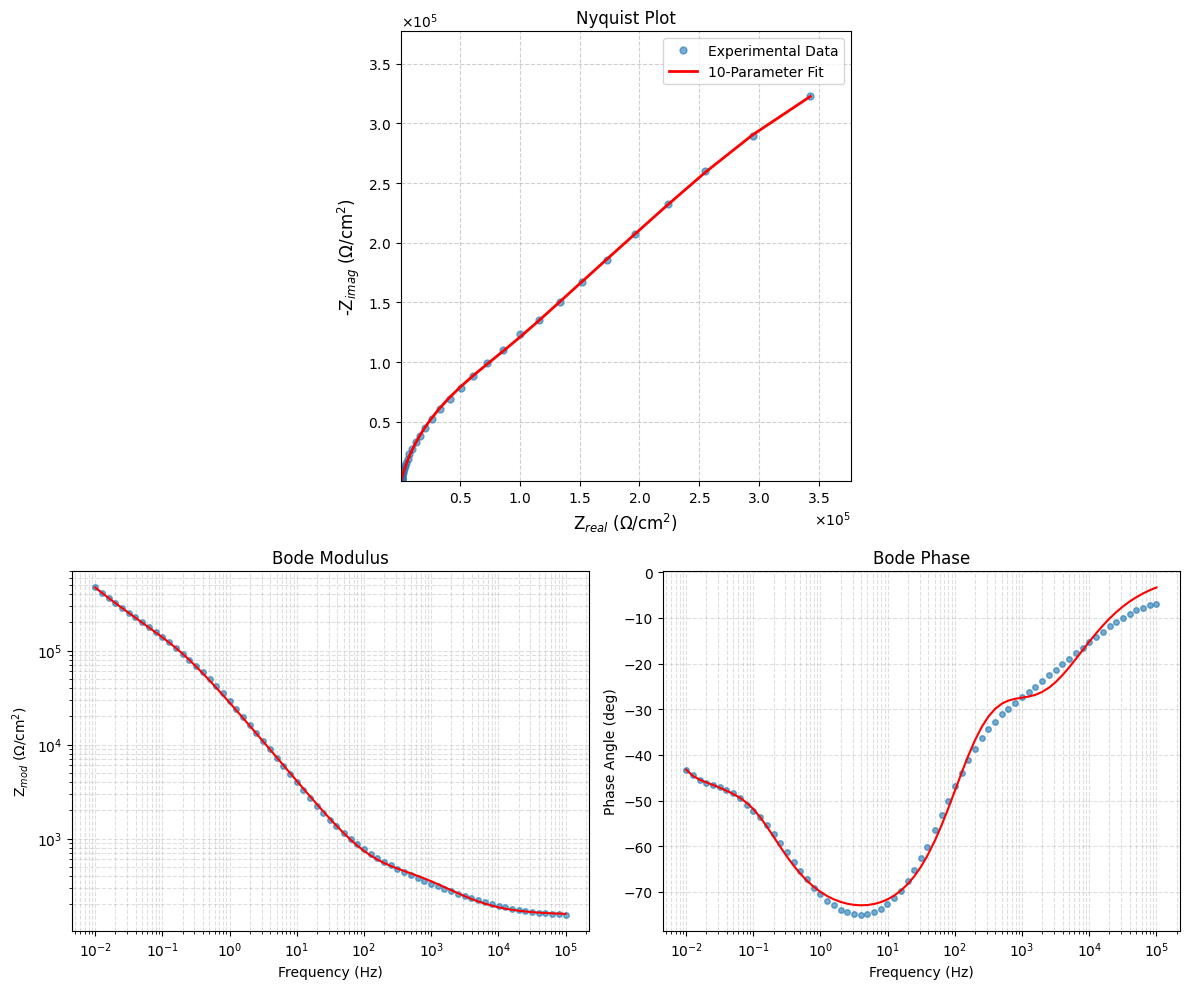

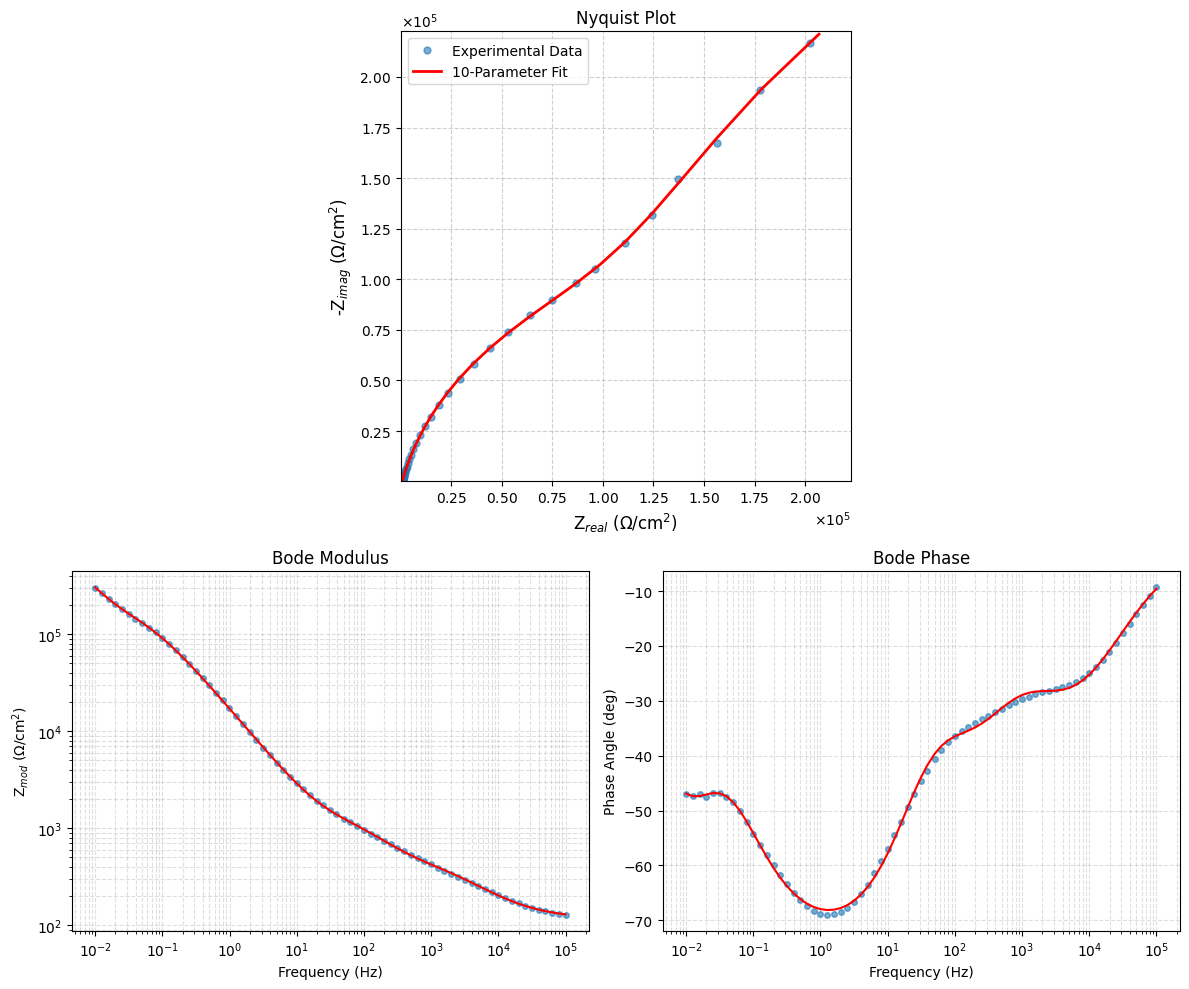

In [45]:
plotter(all_datasets, 'original_eis_data', choice)

In [9]:
end_points_to_drop = 0
freq_condition_max = 1e5
freq_condition_min = 1e-1

def data_to_keep(all_datasets,end_points_to_drop, freq_condition_max, freq_condition_min):

    for dataset in all_datasets:
        freqs = np.array(dataset['original_eis_data']['Freq'])

        combined_condition = (freqs <= freq_condition_max) & (freqs >= freq_condition_min)
        
        keys = ['Freq', 'Zreal', 'Zimag', 'Zmod', 'Zphz', 'Z_data']

        for key in keys:
            if end_points_to_drop > 0:
                dataset['eis_data'][key] = dataset['original_eis_data'][key][combined_condition]
                dataset['eis_data'][key] = dataset['eis_data'][key][:-end_points_to_drop]
            else:
                dataset['eis_data'][key] = dataset['original_eis_data'][key][combined_condition]
                
    return all_datasets

all_datasets = data_to_keep(all_datasets, end_points_to_drop, freq_condition_max, freq_condition_min)

In [14]:
choice = '3RC'

all_datasets = parameter_guesser(all_datasets, choice, 'eis_data', circuits_data)

Fitting Dataset 1/1 (3RC)...


C:\pea\code\parameter_guesser\.venv\Lib\site-packages\impedance\models\circuits\circuits.py:145: UserWarning: Simulating circuit based on initial parameters
  warnings.warn("Simulating circuit based on initial parameters")


Dataset 1 complete. Chi-Square: 8.8621e-04



In [15]:
print(all_datasets[0]['eis_data']['circuit'])


Circuit string: R0-p(R1-p(R2-p(R3,CPE3),CPE2),CPE1)
Fit: True

Initial guesses:
     R0 = 1.57e+02 [Ohm]
     R1 = 4.68e+02 [Ohm]
     R2 = 2.72e+05 [Ohm]
     R3 = 5.12e+05 [Ohm]
  CPE3_0 = 1.94e-05 [Ohm^-1 sec^a]
  CPE3_1 = 1.00e+00 []
  CPE2_0 = 3.72e-06 [Ohm^-1 sec^a]
  CPE2_1 = 9.10e-01 []
  CPE1_0 = 3.56e-06 [Ohm^-1 sec^a]
  CPE1_1 = 7.75e-01 []

Fit parameters:
     R0 = 1.57e+02  (+/- 2.04e+00) [Ohm]
     R1 = 4.68e+02  (+/- 4.81e+01) [Ohm]
     R2 = 2.72e+05  (+/- 4.59e+04) [Ohm]
     R3 = 5.12e+05  (+/- 6.54e+02) [Ohm]
  CPE3_0 = 1.94e-05  (+/- 6.27e-06) [Ohm^-1 sec^a]
  CPE3_1 = 1.00e+00  (+/- 2.86e-01) []
  CPE2_0 = 3.72e-06  (+/- 6.53e-07) [Ohm^-1 sec^a]
  CPE2_1 = 9.10e-01  (+/- 2.13e-02) []
  CPE1_0 = 3.56e-06  (+/- 9.04e-07) [Ohm^-1 sec^a]
  CPE1_1 = 7.75e-01  (+/- 2.48e-02) []



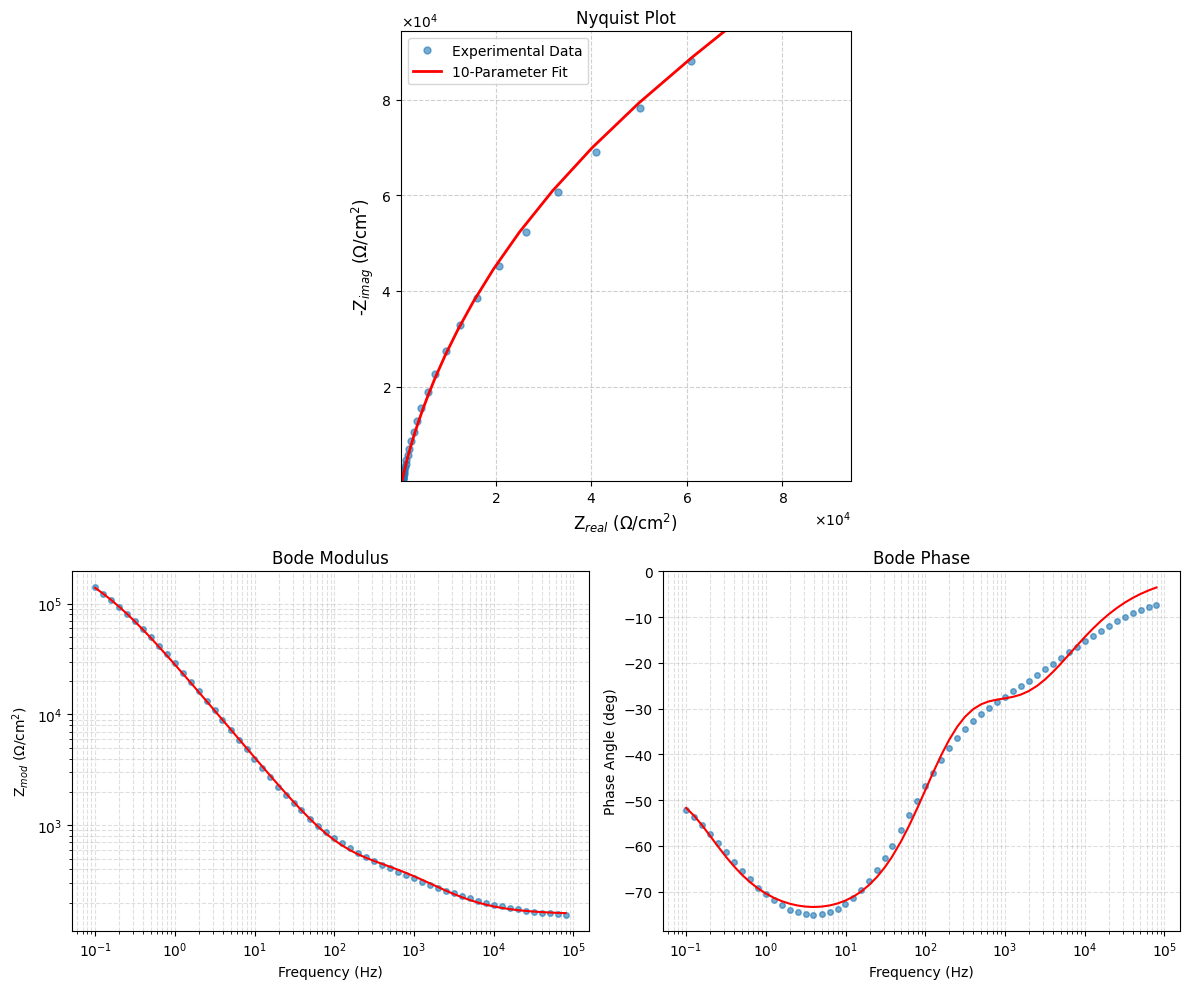

In [16]:
plotter(all_datasets, 'eis_data', choice)

In [34]:
def generate_combined_eis_report(all_datasets, data_key, circuits_data, end_points_to_drop, freq_condition_max, freq_condition_min, output_filename="eis_report.tex"):
    # 1. Infer circuit_string, choice, and bounds automatically from the fitted circuit
    first_circuit = all_datasets[0][data_key]['circuit']
    circuit_string = first_circuit.circuit
    
    # Reverse-lookup the 'choice' key (e.g., '1RC', '2RC') from circuits_data using the string
    choice = "Unknown"
    for key, data in circuits_data.items():
        if data['string'] == circuit_string:
            choice = key
            break

    # 2. Extract parameter matches from the CustomCircuit print output
    first_text = str(first_circuit)
    param_pattern = r"([A-Z0-9_]+)\s+=\s+([0-9.e+-]+)\s+\(\+/-\s+([0-9.e+-]+)\)\s+\[(.*?)\]"
    
    if "Fit parameters:" in first_text:
        fit_section = first_text.split("Fit parameters:")[1]
        matches = re.findall(param_pattern, fit_section)
    else:
        matches = re.findall(param_pattern, first_text)

    # 3. Build Header with \specialcell
    header = r"\textbf{Element} & \textbf{Unit} & \textbf{Bounds}"
    column_setup = "|l|c|c|"
    for dataset in all_datasets:
        # Break the filename at underscores to stack it vertically in the cell
        clean_file_name = dataset[data_key]['name'].replace("_", r"\_ \\ ")
        header += f" & \\textbf{{\\specialcell{{{clean_file_name}}}}}"
        column_setup += "c|"

    # 4. Build Table Rows
    table_rows = ""
    for idx, (p_name, _, _, p_unit) in enumerate(matches):
        # --- DYNAMIC MAPPING ---
        if "CPE" in p_name:
            num = re.search(r'CPE(\d+)', p_name).group(1) if re.search(r'CPE(\d+)', p_name) else ""
            display_name = f"Q_{{{num}}}" if p_name.endswith("_0") else f"n_{{{num}}}"
        elif "PW" in p_name:
            num = re.search(r'PW(\d+)', p_name).group(1) if re.search(r'PW(\d+)', p_name) else ""
            display_name = f"Y_{{o,{num}}}" if p_name.endswith("_0") else f"B_{{{num}}}"
        elif p_name.startswith("L"):
            num = re.search(r'L(\d+)', p_name).group(1) if re.search(r'L(\d+)', p_name) else ""
            display_name = f"L_{{{num}}}"
        elif p_name[0].isdigit(): 
            p_idx, p_type = p_name.split("_")
            display_name = rf"W_{{{p_idx},R}}" if p_type == "0" else rf"W_{{{p_idx},\tau}}"
        elif p_name.startswith("R"):
            num = re.search(r'R(\d+)', p_name).group(1) if re.search(r'R(\d+)', p_name) else ""
            display_name = f"R_{{{num}}}"
        else:
            display_name = p_name

        clean_p_name = f"${display_name}$"
        
        # Format Units
        clean_unit = p_unit.replace("Ohm", r"$\Omega$")\
                           .replace("^-1", r"$^{-1}$")\
                           .replace("^-1/2", r"$^{-1/2}$")\
                           .replace("^1/2", r"$^{1/2}$")\
                           .replace("^a", r"$^{a}$")
                           
        if not clean_unit.strip() or clean_unit == "[]": 
            clean_unit = "-"

        # --- GET BOUNDS DYNAMICALLY ---
        if choice != "Unknown" and p_name in circuits_data[choice]['bounds']:
            b_low, b_high = circuits_data[choice]['bounds'][p_name]['bounds']
            bounds_str = f"$[{b_low:.1e}, {b_high:.1e}]$"
        else:
            bounds_str = "-"
            
        row_content = f"{clean_p_name} & {clean_unit} & {bounds_str}"
        
        # Values and Errors
        for dataset in all_datasets:
            txt = str(dataset[data_key]['circuit'])
            m = re.search(rf"{p_name}\s+=\s+([0-9.e+-]+)\s+\(\+/-\s+([0-9.e+-]+)\)", txt)
            if m:
                val, err = m.groups()
                row_content += f" & ${float(val):.2e} \\pm {float(err):.1e}$"
            else:
                row_content += " & N/A"
        
        table_rows += rf"        {row_content} \\ \hline" + "\n"

    # 5. Chi-Squared Row
    chi_row = r"\textbf{$\chi^2$} & - & - " 
    for dataset in all_datasets:
        chi = dataset[data_key]['chi_sq']
        chi_row += f" & ${chi:.3e}$"
    table_rows += rf"        {chi_row} \\ \hline" + "\n"

    # 6. Plot Sections and Fitted Data Tables
    plot_sections = ""
    for dataset in all_datasets:
        d_name = dataset[data_key]['name']
        clean_d_name = d_name.replace("_", r"\_")
        plot_file = f"plots_{d_name.replace('.DTA', '')}_{choice}.pdf"
        
        # Add Plot Page
        plot_sections += r"""
\newpage
\section*{Analysis Results: """ + clean_d_name + r"""}
\begin{center}
    \includegraphics[width=0.7\textwidth]{""" + plot_file + r"""}
    \captionof{figure}{EIS Fit Results for """ + clean_d_name + r"""}
\end{center}
"""

        # Extract data for the multi-page table
        freq = dataset[data_key]['Freq']
        z_fit = dataset[data_key]['Z_fit']
        
        z_real = z_fit.real
        z_imag_neg = -z_fit.imag
        z_mod = np.abs(z_fit)
        z_phase = np.angle(z_fit, deg=True)
        
        # Add Multi-page Table Page
        plot_sections += r"""
\begin{landscape}
\section*{Fitted Data: """ + clean_d_name + r"""}
\begin{center}
\tiny 
\begin{longtable}{|c|c|c|c|c|}
    \hline
    \textbf{Frequency (Hz)} & \textbf{Z$_{real}$ ($\Omega$)} & \textbf{-Z$_{imag}$ ($\Omega$)} & \textbf{Z$_{mod}$ ($\Omega$)} & \textbf{Z$_{phase}$ ($^\circ$)} \\ \hline
    \endfirsthead
    
    \multicolumn{5}{c}%
    {{\bfseries \tablename\ \thetable{} -- continued from previous page}} \\
    \hline
    \textbf{Frequency (Hz)} & \textbf{Z$_{real}$ ($\Omega$)} & \textbf{-Z$_{imag}$ ($\Omega$)} & \textbf{Z$_{mod}$ ($\Omega$)} & \textbf{Z$_{phase}$ ($^\circ$)} \\ \hline
    \endhead
    
    \hline \multicolumn{5}{|r|}{{Continued on next page}} \\ \hline
    \endfoot
    
    \hline
    \endlastfoot
"""
        # Populate table rows
        for f, zr, zi, zm, zp in zip(freq, z_real, z_imag_neg, z_mod, z_phase):
            plot_sections += f"    {f:.4e} & {zr:.4e} & {zi:.4e} & {zm:.4e} & {zp:.4f} \\\\\n"
        
        plot_sections += r"""\end{longtable}
\end{center}
\end{landscape}
"""

    # 7. Format descriptions
    if data_key == 'original_eis_data':
        data_description = "original data"
    else:
        formatted_freq_max = f"{float(freq_condition_max):.0e}"
        formatted_freq_min = f"{float(freq_condition_min):.0e}"
        data_description = (
            f"altered data, first {end_points_to_drop} points removed and "
            f"points with $freq > {formatted_freq_max}$ and "
            f"$freq < {formatted_freq_min}$ removed"
        )
    
    # 8. Final Assembly
    tex_final = r"""
\documentclass[10pt]{article}
\usepackage[utf8]{inputenc}
\usepackage{graphicx}
\usepackage{amsmath, amssymb}
\usepackage{geometry}
\usepackage{caption} 
\usepackage{longtable} 
\usepackage{lscape} 
\usepackage{adjustbox} % <-- Added adjustbox to shrink table only if it overflows
\geometry{a4paper, margin=0.5in, landscape} 

% Define a special command to allow multiline cells in the table headers
\newcommand{\specialcell}[2][c]{%
  \begin{tabular}[#1]{@{}c@{}}#2\end{tabular}}

\begin{document}

\section*{Comparative EIS Kinetics Report}
\textbf{Model Structure:} \texttt{""" + circuit_string.replace("_", r"\_") + r"""} \\
\textbf{Used data:} """ + data_description + r"""

\begin{center}
""" + f"    \\includegraphics[width=0.4\\textwidth]{{circuits/{choice}.png}}" + r"""
\end{center}

\renewcommand{\arraystretch}{1.6} 
\begin{table}[h!]
    \centering
    \begin{adjustbox}{max width=\textwidth} % <-- Scales down ONLY if it exceeds textwidth
    \begin{tabular}{""" + column_setup + r"""}
        \hline
        """ + header + r""" \\ \hline
""" + table_rows + r"""
    \end{tabular}
    \end{adjustbox}
\end{table}

""" + plot_sections + r"""

\end{document}
"""

    if not output_filename.endswith(".tex"):
        output_filename += ".tex"
        
    with open(output_filename, "w", encoding="utf-8") as f:
        f.write(tex_final)

In [58]:
generate_combined_eis_report(all_datasets, "eis_data", circuits_data, end_points_to_drop, freq_condition_max, freq_condition_min, "AA2024_LNV3_4_lowfreq_v4.tex")

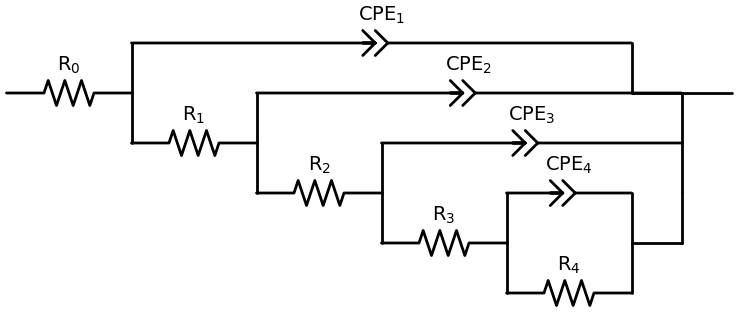

In [41]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    d += elm.Resistor().right().length(2.5).label(r'$\text{R}_{0}$')
    d.push()
    d += elm.Line().up().length(1)
    d += elm.CPE().right().length(10).label(r'$\text{CPE}_{1}$')
    d += elm.Line().down().length(1)
    d += elm.Line().right().length(2)
    d.pop()
    d += elm.Line().down().length(1)
    d += elm.Resistor().right().length(2.5).label(r'$\text{R}_{1}$')
    d.push()
    d += elm.Line().up().length(1)
    d += elm.CPE().right().length(8.5).label(r'$\text{CPE}_{2}$')
    d += elm.Line().down().length(1)
    d.pop()
    d += elm.Line().down().length(1)
    d += elm.Resistor().right().length(2.5).label(r'$\text{R}_{2}$')
    d.push()
    d += elm.Line().up().length(1)
    d += elm.CPE().right().length(6).label(r'$\text{CPE}_{3}$')
    d += elm.Line().down().length(1)
    d.pop()
    d += elm.Line().down().length(1)
    d += elm.Resistor().right().length(2.5).label(r'$\text{R}_{3}$')
    d.push()
    d += elm.Line().up().length(1)
    d += elm.CPE().right().length(2.5).label(r'$\text{CPE}_{4}$')
    d += elm.Line().down().length(1)
    d.pop()
    d += elm.Line().down().length(1)
    d += elm.Resistor().right().length(2.5).label(r'$\text{R}_{4}$')
    d += elm.Line().up().length(1)
    d += elm.Line().right().length(1)
    d += elm.Line().up().length(1)
    
    d.save('4RC.png', dpi= 500, transparent=True)
    
    
    

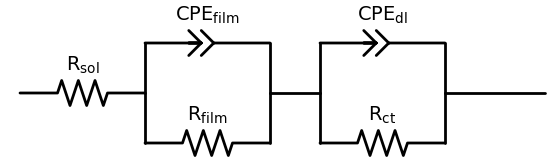

In [18]:
with schemdraw.Drawing() as d:
    d += elm.Resistor().right().length(2.5).label(r'$\text{R}_{\text{sol}}$')
    d.push()
    d += elm.Line().up().length(1)
    d += elm.CPE().right().length(2.5).label(r'$\text{CPE}_{\text{film}}$')
    d += elm.Line().down().length(1)
    d.pop()
    d += elm.Line().down().length(1)
    d += elm.Resistor().right().length(2.5).label(r'$\text{R}_{\text{film}}$')
    d += elm.Line().up().length(1)
    d += elm.Line().right().length(1)
    
    d.push()
    d += elm.Line().up().length(1)
    d += elm.CPE().right().length(2.5).label(r'$\text{CPE}_{\text{dl}}$')
    d += elm.Line().down().length(1)
    d.pop()
    d += elm.Line().down().length(1)
    d += elm.Resistor().right().length(2.5).label(r'$\text{R}_{\text{ct}}$')
    d += elm.Line().up().length(1)
    d += elm.Line().right().length(2)
    
    d.save('2RC_voigt.pdf', transparent=True)